|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Math, numpy, pytorch<h1>|
|<h2>Lecture:</h2>|<h1><b>Entropy and cross-entropy<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

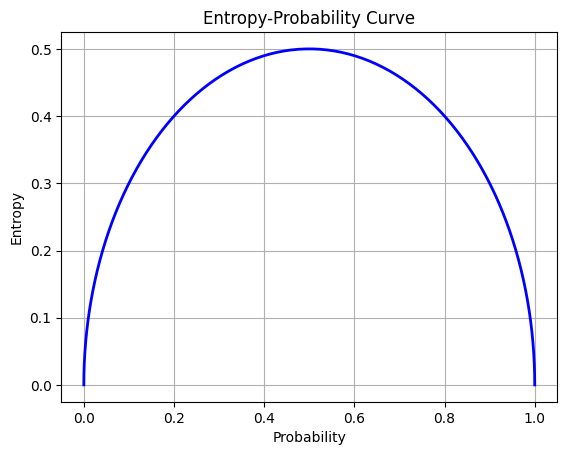

In [11]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt


#Appromixating the graph with a semicircle instead of actually calculating the entropy using the mathematical formula for all probabilities between 0 and 1
theta = np.linspace(0, np.pi, 100)

# Center at x = 0.5, y = 0 with radius r = 0.5
r = 0.5
x_center = 0.5
y_center = 0.0

x = x_center + r * np.cos(theta)
y = y_center + r * np.sin(theta)

# Plotting
fig, ax = plt.subplots()
ax.plot(x, y, color="blue", linewidth=2)
ax.set_xlabel("Probability")
ax.set_ylabel("Entropy")
ax.set_title("Entropy-Probability Curve")
ax.grid(True)
plt.show()

# Reminder of entropy:

$$H(p) = -\sum_x p(x)\log(p(x))$$

#Entropy is max for 0.5 probability and it tapers off in both directions towards 0 as the probability goes to 1 towards right and 0 towards left.

In [2]:
# probability of an event happening
p = .25

# NOT the correct formula!
H = -( p*np.log(p) )
print('Wrong entropy: ' + str(H))

Wrong entropy: 0.34657359027997264


In [ ]:
#probability of the event hot happening is not included so it is wrong

In [3]:
# the correct way to compute entropy
x = [.25,.75]

H = 0
for p in x:
  H -= p*np.log(p)

print('Correct entropy: ' + str(H))

Correct entropy: 0.5623351446188083


In [4]:
# also correct, written out for N=2 events
H = -( p*np.log(p) + (1-p)*np.log(1-p) )
print('Correct entropy: ' + str(H))

Correct entropy: 0.5623351446188083


# Cross-entropy

In [5]:
# note: all probs must sum to 1!
p = [   1,0   ] # sum=1 Probability from known labels of the data (Example: is a cat, not a cat)
q = [ .25,.75 ] # sum=1 Probability predicted by the model for the same labels

H = 0
for i in range(len(p)):
  H -= p[i]*np.log(q[i])

print('Cross entropy: ' + str(H))

Cross entropy: 1.3862943611198906


In [7]:
# also correct, written out for N=2 events
H = -( p[0]*np.log(q[0]) + p[1]*np.log(q[1]) )
print('Correct entropy: ' + str(H))

# simplification
H = -np.log(q[0])
print('Manually simplified: ' + str(H))

Correct entropy: 1.3862943611198906
Manually simplified: 1.3862943611198906


In [9]:
# now using pytorch
import torch
import torch.nn.functional as F

# note: inputs must be Tensors
q_tensor = torch.Tensor(q)
p_tensor = torch.Tensor(p)

F.binary_cross_entropy(q_tensor,p_tensor)#Order should be q first and then p. Becomes more intuitive when we apply the concept in future lectures.

tensor(1.3863)